## Importing Library

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## Loading the Dataset

In [2]:
df = pd.read_csv("Carbon Emission - LMS.csv")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (10000, 20)


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


## Understanding the Data

In [3]:
print("Shapes:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicates rows:", df.duplicated().sum())

Shapes: (10000, 20)

Column names:
['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source', 'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill', 'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km', 'Waste Bag Size', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour', 'Energy efficiency', 'Recycling', 'Cooking_With', 'CarbonEmission']

Data types:
Body Type                        object
Sex                              object
Diet                             object
How Often Shower                 object
Heating Energy Source            object
Transport                        object
Vehicle Type                     object
Social Activity                  object
Monthly Grocery Bill              int64
Frequency of Traveling by Air    object
Vehicle Monthly Distance Km       int64
Waste Bag Size                   object
Waste Bag Weekly Count            int64
How Long TV PC Da

## Exploratory Data Analysis

count    10000.000000
mean      2269.147300
std       1017.675247
min        306.000000
25%       1538.000000
50%       2080.000000
75%       2768.000000
max       8377.000000
Name: CarbonEmission, dtype: float64


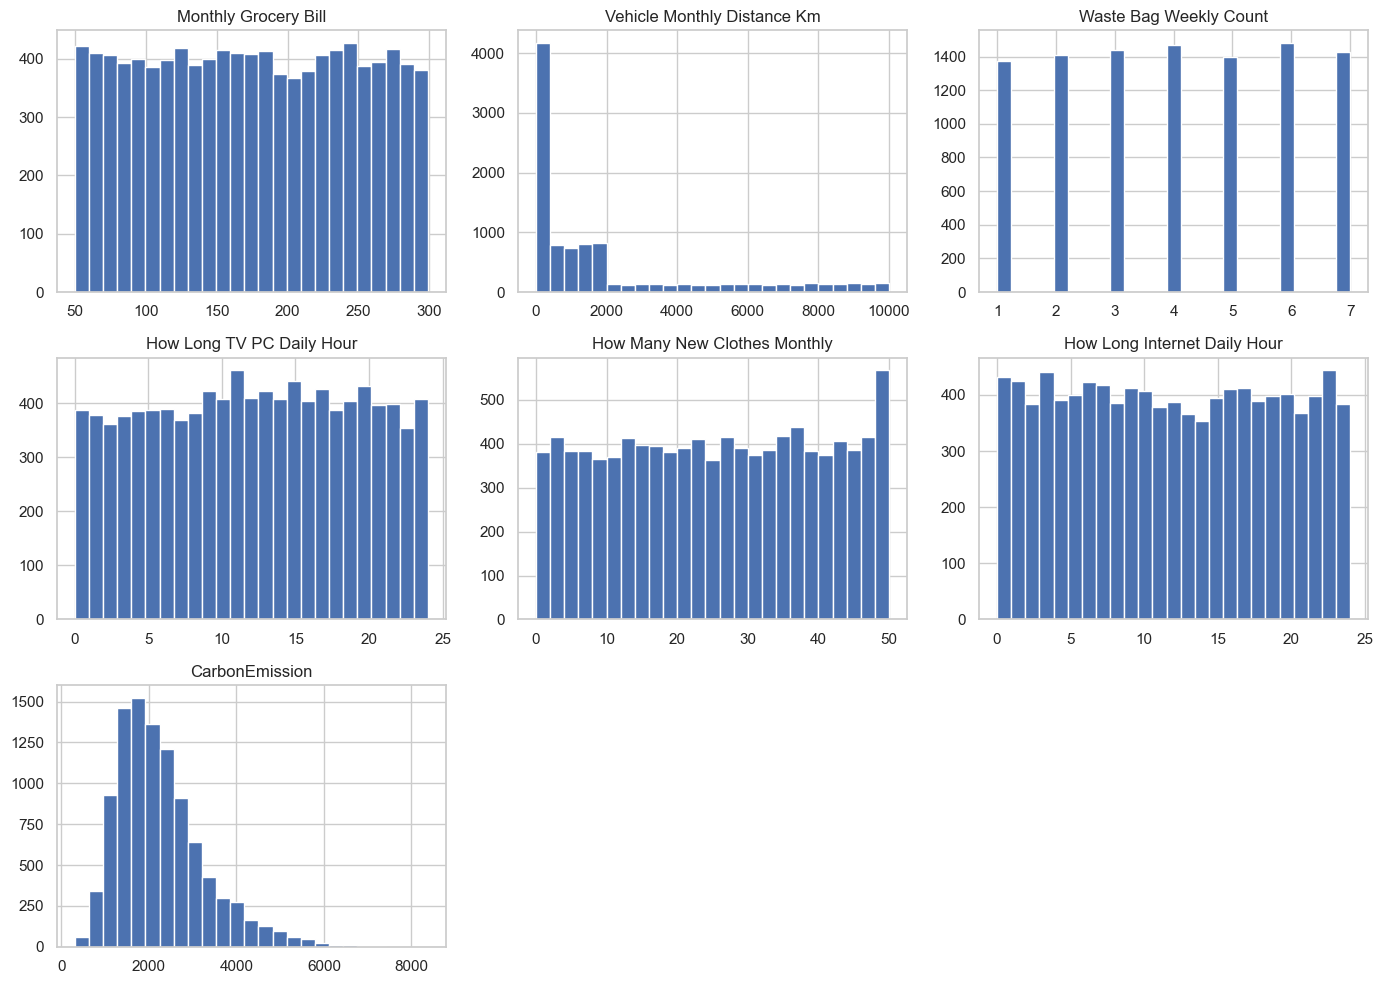

In [4]:
print(df["CarbonEmission"].describe())

numeric_cols = df.select_dtypes(include = np.number).columns

df[numeric_cols].hist(figsize = (14,10), bins = 25)
plt.tight_layout()
plt.show()

## Target Variable

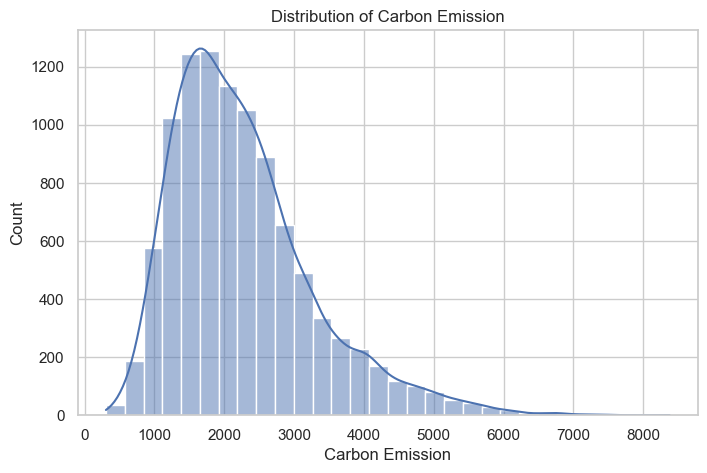

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["CarbonEmission"], bins=30, kde=True)

plt.title("Distribution of Carbon Emission")
plt.xlabel("Carbon Emission")
plt.ylabel("Count")

plt.show()

## Correlation with Carbon Emission

CarbonEmission                  1.000000
Vehicle Monthly Distance Km     0.594171
How Many New Clothes Monthly    0.198887
Waste Bag Weekly Count          0.159193
Monthly Grocery Bill            0.081587
How Long Internet Daily Hour    0.043878
How Long TV PC Daily Hour       0.012985
Name: CarbonEmission, dtype: float64


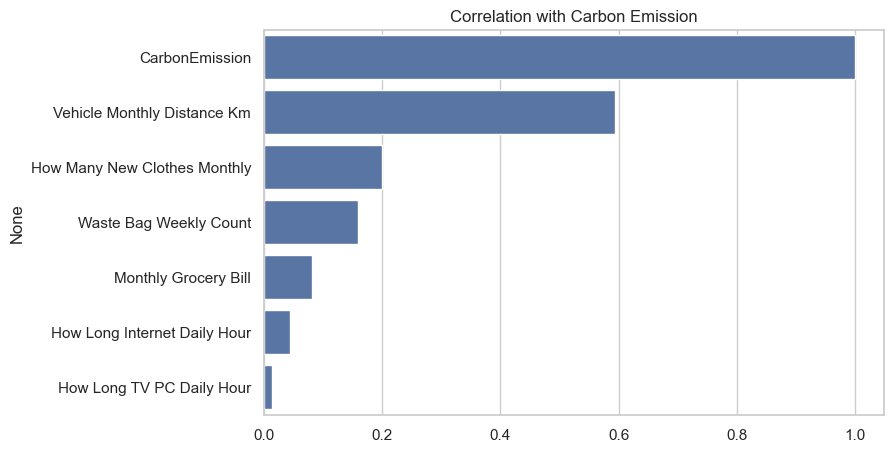

In [6]:
corr = df[numeric_cols].corr()["CarbonEmission"].sort_values(ascending = False)
print(corr)

plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Correlation with Carbon Emission")

plt.show()

## Categorical EDA

In [7]:
categorical_eda = [
    "Transport",
    "Frequency of Traveling by Air",
    "Heating Energy Source",
    "Diet",
    "Energy efficiency",
    "Waste Bag Size"
]

for col in categorical_eda:
    print("\nAverage CarbonEmission by", col)
    print(df.groupby(col)["CarbonEmission"].mean().sort_values(ascending=False))


Average CarbonEmission by Transport
Transport
private         2980.878012
public          1965.789314
walk/bicycle    1879.738547
Name: CarbonEmission, dtype: float64

Average CarbonEmission by Frequency of Traveling by Air
Frequency of Traveling by Air
very frequently    3026.455906
frequently         2362.866482
rarely             1945.872830
never              1716.337129
Name: CarbonEmission, dtype: float64

Average CarbonEmission by Heating Energy Source
Heating Energy Source
coal           2495.060246
wood           2296.815672
natural gas    2248.124289
electricity    2039.379702
Name: CarbonEmission, dtype: float64

Average CarbonEmission by Diet
Diet
omnivore       2391.980738
pescatarian    2251.835552
vegetarian     2216.814408
vegan          2215.761314
Name: CarbonEmission, dtype: float64

Average CarbonEmission by Energy efficiency
Energy efficiency
No           2286.656628
Sometimes    2269.151314
Yes          2252.135404
Name: CarbonEmission, dtype: float64

Average Ca

## Feature Engineering

In [8]:
data =df.copy()

data.columns = [
    c.strip().lower().replace(" ","_").replace("-","_").replace("/","_")
    for c in data.columns
]

def parse_list(value):
    try:
        return ast.literal_eval(value) if isinstance(value,str) else []
    except:
        return []

for col, prefix in [("recycling", "recycle"), ("cooking_with", "cook")]:
    parsed = data[col].apply (parse_list)
    items = sorted({item for row in parsed for item in row})

    for item in items:
        data[f"{prefix}_{item.lower()}"] = parsed.apply(
            lambda x: int(item in x)
        )

    data[f"{prefix}_count"] = parsed.apply(len)
    data.drop(columns=[col], inplace=True)

air_map = {
    "never": 0,
    "rarely" : 1,
    "frequently": 2,
    "very frequently": 3
}

waste_map = {
    "small": 1,
    "medium": 2,
    "large": 3,
    "extra large": 4
}

data["total_screen_time_hours"] = (
    data["how_long_tv_pc_daily_hour"]+
    data["how_long_internet_daily_hour"])

data["air_travel_score"] = data["frequency_of_traveling_by_air"].map(air_map)

data["waste_volume_index"] = (
    data["waste_bag_size"].map(waste_map)* data["waste_bag_weekly_count"])

data["lifestyle_spend_index"] = (
    data["monthly_grocery_bill"] + data["how_many_new_clothes_monthly"]*10)

print("New shape:", data.shape)
data.head()

New shape: (10000, 33)


,body_type,sex,diet,how_often_shower,heating_energy_source,transport,vehicle_type,social_activity,monthly_grocery_bill,frequency_of_traveling_by_air,...,cook_airfryer,cook_grill,cook_microwave,cook_oven,cook_stove,cook_count,total_screen_time_hours,air_travel_score,waste_volume_index,lifestyle_spend_index
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,...,0,0,0,1,1,2,8,2,12,490
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,...,0,0,1,0,1,2,14,1,12,494
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,...,0,0,1,1,0,2,20,0,1,608
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,...,1,1,1,0,0,3,27,1,6,207
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,...,0,0,0,1,0,1,9,3,3,316


## Checking the Engineered Data


In [9]:
print("Missing values after feature engineering:")
print(data.isnull().sum().sort_values(ascending = False).head(10))

print("\nTarget summary:")
print(data["carbonemission"].describe())

Missing values after feature engineering:
vehicle_type       6721
body_type             0
cook_microwave        0
recycle_metal         0
recycle_paper         0
recycle_plastic       0
recycle_count         0
cook_airfryer         0
cook_grill            0
cook_oven             0
dtype: int64

Target summary:
count    10000.000000
mean      2269.147300
std       1017.675247
min        306.000000
25%       1538.000000
50%       2080.000000
75%       2768.000000
max       8377.000000
Name: carbonemission, dtype: float64


## Train-Test Split

In [10]:
X = data.drop(columns=["carbonemission"])
y = data["carbonemission"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 8000
Testing rows: 2000


## Preprocessing Pipeline

In [11]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 21
Categorical columns: 11


## Evalution Function 

In [12]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    n = len(y_test)
    p = X_test.shape[1]
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)

    return [name, r2, adjusted_r2, rmse, mae]

## Linear Regression

In [13]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_results = evaluate_model(
    "Linear Regression", linear_model, X_test, y_test
)

linear_results

['Linear Regression',
 0.9382042883202238,
 0.9371989691673246,
 np.float64(253.47488286739315),
 164.9423570361936]

## Ridge and Lasso Regression 

In [14]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model",Ridge(alpha=10))
])

lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1, max_iter=20000))])

ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

ridge_results = evaluate_model("Ridge", ridge_model, X_test, y_test)
lasso_results = evaluate_model("Lasso", lasso_model, X_test, y_test)

ridge_results, lasso_results

(['Ridge',
  0.9382008553311555,
  0.9371954803289171,
  np.float64(253.48192352113165),
  164.81946273135114],
 ['Lasso',
  0.9382133892233719,
  0.9372082181278701,
  np.float64(253.45621704708165),
  164.8956221687025])

## Non-Linear Regression Models

In [32]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

rf_results = evaluate_model("Random Forest", rf_model, X_test, y_test)
gb_results = evaluate_model("Gradient Boosting", gb_model, X_test, y_test)

rf_results, gb_results

(['Random Forest',
  0.9309793284101653,
  0.9298564705093647,
  np.float64(267.88312237471627),
  198.75900925496728],
 ['Gradient Boosting',
  0.9483899250361102,
  0.9475503101917561,
  np.float64(231.64504073271),
  170.0661138524129])

## Comapring all models

In [33]:
results = pd.DataFrame(
    [
        linear_results,
        ridge_results,
        lasso_results,
        rf_results,
        gb_results
    ],
    columns=["Model", "R2", "Adjusted R2", "RMSE", "MAE"]
)

results.sort_values("R2", ascending=False)

,Model,R2,Adjusted R2,RMSE,MAE
4,Gradient Boosting,0.948390,0.947550,231.645041,170.066114
2,Lasso,0.938213,0.937208,253.456217,164.895622
0,Linear Regression,0.938204,0.937199,253.474883,164.942357
1,Ridge,0.938201,0.937195,253.481924,164.819463
3,Random Forest,0.930979,0.929856,267.883122,198.759009


## Model Performance Plot

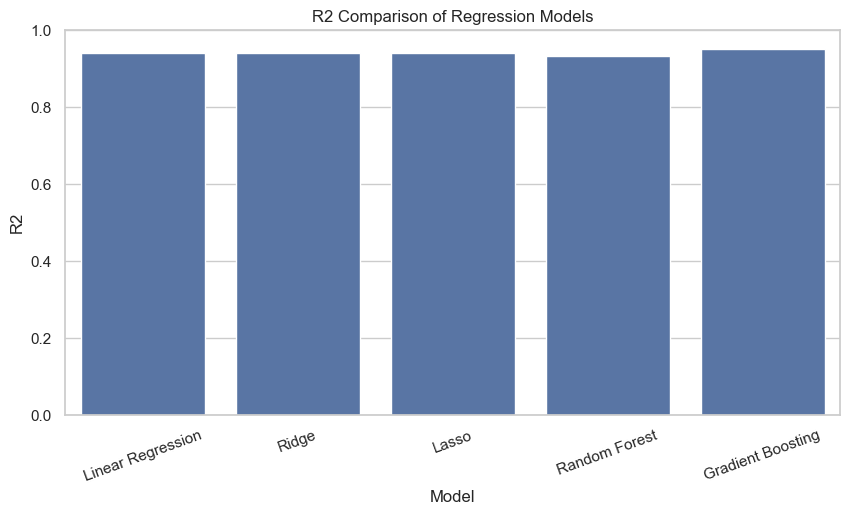

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Model", y="R2")
plt.ylim(0, 1)
plt.title("R2 Comparison of Regression Models")
plt.xticks(rotation=20)
plt.show()

## Residual Diagnostics

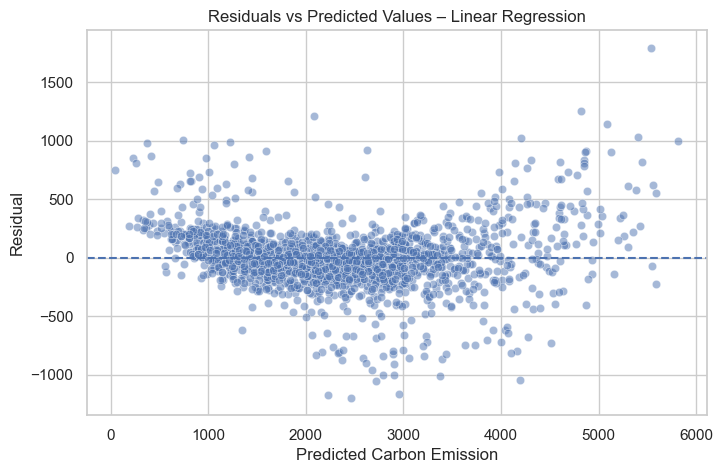

In [23]:
linear_pred = linear_model.predict(X_test)
linear_residuals = y_test - linear_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=linear_pred, y=linear_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Values – Linear Regression")
plt.xlabel("Predicted Carbon Emission")
plt.ylabel("Residual")
plt.show()


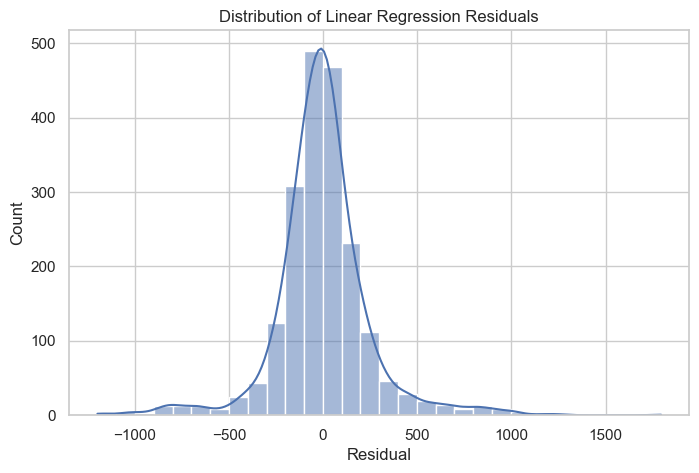

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(linear_residuals, bins=30, kde=True)
plt.title("Distribution of Linear Regression Residuals")
plt.xlabel("Residual")

plt.show()

## Feature imortance - gradienrt Bossting

num__vehicle_monthly_distance_km                      0.375195
num__air_travel_score                                 0.153169
cat__vehicle_type_electric                            0.120750
cat__frequency_of_traveling_by_air_very frequently    0.079998
num__waste_volume_index                               0.049403
cat__vehicle_type_petrol                              0.037373
num__lifestyle_spend_index                            0.034134
cat__body_type_obese                                  0.025979
cat__sex_female                                       0.016210
cat__vehicle_type_hybrid                              0.014333
cat__heating_energy_source_electricity                0.013131
cat__sex_male                                         0.012424
cat__frequency_of_traveling_by_air_frequently         0.010420
num__how_many_new_clothes_monthly                     0.010306
cat__heating_energy_source_coal                       0.009396
dtype: float64


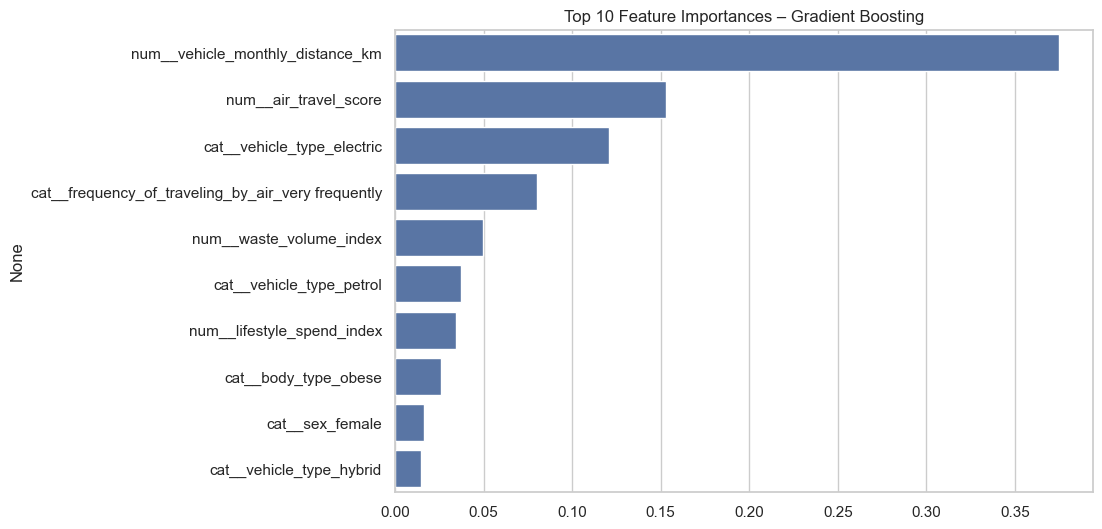

In [25]:
feature_names = gb_model.named_steps["preprocessor"].get_feature_names_out()
importance = gb_model.named_steps["model"].feature_importances_

feature_importance = pd.Series(
    importance, index=feature_names
).sort_values(ascending=False)

print(feature_importance.head(15))

plt.figure(figsize=(9, 6))
sns.barplot(
    x=feature_importance.head(10).values,
    y=feature_importance.head(10).index
)
plt.title("Top 10 Feature Importances – Gradient Boosting")
plt.show()